# Check correlation between Delta Z and Delta V
We want to check if the velocities output by MultiVelo are somehow connected to motif accessibility, represented by ChromVAR z-scores. We compare pairs of cells that close within the RNA embedding but have vastly different accessibility scores and compute differences in velocity. Ultimately we can compute a correlation between the Delta 

In [2]:
import scanpy as sc
import numpy as np 
import matplotlib.pyplot as plt
import multivelo as mv
import pandas as pd
import scvelo as scv
from pathlib import Path
from scipy.spatial.distance import cdist, euclidean
from scipy.optimize import linear_sum_assignment
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"

scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
scv.settings.figdir = rf"{python_data_dir}\multivelo_comparison"
scv.settings.plot_prefix = ""
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [3]:
mv_data = sc.read_h5ad(rf"{python_data_dir}\multivelo_results.h5ad")
adata_atac = sc.read_h5ad(fr"{python_data_dir}\all_atac_aggregated_peaks.h5ad")

In [4]:
adata_atac = adata_atac[mv_data.obs_names, mv_data.var_names]
nn_idx = np.loadtxt(rf"{python_data_dir}/nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt(rf"{python_data_dir}/nn_dist.txt", delimiter=',')
mv.knn_smooth_chrom(adata_atac, nn_idx, nn_dist)

In [5]:
z_scores = sc.read_h5ad(rf"{python_data_dir}\z_scores_raw.h5ad")
z_scores.obs_names = [i[9:-2] for i in z_scores.obs_names.values]
intersect_cells = np.intersect1d(adata_atac.obs_names, z_scores.obs_names)

adata_atac = adata_atac[intersect_cells,:]
z_scores = z_scores[intersect_cells,:]
mv_data = mv_data[intersect_cells,:]

In [6]:
mv.velocity_graph(mv_data)
mv.latent_time(mv_data)

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:29) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


computing velocity embedding
    finished (0:00:04) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


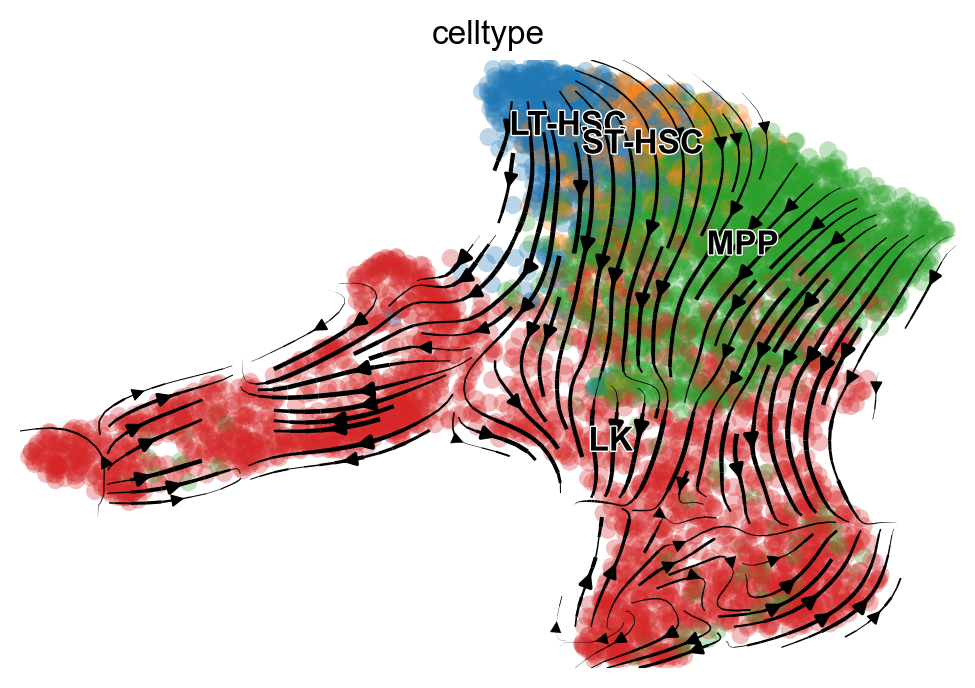

In [7]:
mv.velocity_embedding_stream(mv_data, basis='umap', color='celltype')

In [ ]:
tfs = ["HOXA9", "SPI1", "CEBPA", "GATA1", "GATA2", "MYC"]

In [ ]:
umap_velos = mv_data.obsm["velo_s_norm_umap"]
velo_df = pd.DataFrame(umap_velos, index=mv_data.obs_names.values)
velo_df.rename(columns={0:"vx", 1:"vy"}, inplace=True)
velo_df.index.rename("cell", inplace=True)
velo_df["celltype"] = mv_data.obs["celltype"]
velo_df[["x", "y"]] = mv_data.obsm["X_umap"]

for tf in tfs:
    velo_df[tf] = mv_data.obs[f"{tf}_zscore"]

# mpp_subset = velo_df[velo_df["celltype"] == "MPP"]
# non_mpp_subset = velo_df[velo_df["celltype"] != "MPP"]

velo_df = velo_df.loc[velo_df["celltype"]!="LK",:]

In [ ]:
from sklearn.neighbors import NearestNeighbors

def _first_non_nan(matrix):
    """
    Row-wise first non-NaN value. Columns are assumed already ordered by
    distance (nearest first), so this picks the nearest still-valid
    candidate for each row. Translates the R idiom:
        apply(x, 1, function(x) x[which(!is.na(x))[1]])
    """
    result = np.full(matrix.shape[0], np.nan)
    for i in range(matrix.shape[0]):
        row = matrix[i]
        valid = row[~np.isnan(row)]
        if valid.size:
            result[i] = valid[0]
    return result


def pair_cells_mnn(gene_atac, z_scores, velo_df, mv_data,
                    celltype="MPP", k=10, coord_cols=("x", "y")):
    """
    Iterative mutual-nearest-neighbor 1-to-1 pairing of 'high' vs 'low'
    z-score cells for a single gene, translated from an R implementation
    (match_cells()).

    Unlike a Hungarian-assignment pairing, this does NOT force every hi/lo
    cell into a pair. Each round: for every still-unmatched 'high' cell,
    find its nearest still-available 'low' neighbor; then check that THAT
    'low' cell's nearest still-available 'high' neighbor maps back to the
    same 'high' cell (i.e. they're mutual nearest neighbors). Only mutual
    pairs are locked in; the round repeats on whatever remains unmatched
    until a round locks in no new pairs. Cells that never find a mutual
    partner are dropped, so the result can cover far fewer than all hi/lo
    cells - that's expected, matching the R behavior.

    Returns a DataFrame with columns 'partner_hi', 'partner_lo'.
    """
    # 1. Quantile labels for this one gene (same as the Hungarian version)
    gene_data = z_scores[:, gene_atac].X.flatten()
    labels = pd.qcut(gene_data, q=[0, 0.25, 0.75, 1.0], labels=["low", "med", "high"])
    velo_df[gene_atac] = pd.Series(labels, index=z_scores.obs_names).reindex(mv_data.obs_names)

    # 2. Restrict to the cell type of interest. 'med' cells are kept in the
    #    neighbor search space (like the R code's neighbor_obj spanning the
    #    whole object) so they can be skipped over as candidates, exactly as
    #    the R masking step drops any neighbor that isn't in group1/group2.
    ct_mask = velo_df["celltype"] == celltype
    subset = velo_df.loc[ct_mask, list(coord_cols) + [gene_atac]].dropna(subset=[gene_atac])
    if subset.empty:
        return pd.DataFrame(columns=["partner_hi", "partner_lo"])

    subset = subset.reset_index()  # keep original obs index as a column; use 0..n-1 as positions
    obs_id_col = subset.columns[0]
    obs_ids = subset[obs_id_col].to_numpy()

    hi_pos = subset.index[subset[gene_atac] == "high"].to_numpy()
    lo_pos = subset.index[subset[gene_atac] == "low"].to_numpy()
    if hi_pos.size == 0 or lo_pos.size == 0:
        return pd.DataFrame(columns=["partner_hi", "partner_lo"])

    # 3. KNN index matrix over ALL cells in `subset` (hi + med + lo) - this
    #    mirrors the R code's neighbor_obj/search_space. Column 0 is each
    #    cell's own position (self, distance 0); columns 1:k+1 are its k
    #    nearest neighbors, closest first.
    coords = subset[list(coord_cols)].values
    n_neighbors = min(k + 1, len(subset))
    if n_neighbors < 2:
        return pd.DataFrame(columns=["partner_hi", "partner_lo"])
    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(coords)
    _, nn_idx = nn.kneighbors(coords)

    # 4. Iterative mutual-nearest-neighbor matching, translated from the R
    #    match_cells() loop.
    hi_set = set(hi_pos.tolist())
    lo_set = set(lo_pos.tolist())
    allowed = hi_set | lo_set

    unmatched_hi = hi_pos.copy()
    unmatched_lo = lo_pos.copy()
    matched_pairs = []

    n_prev_unmatched = len(unmatched_hi) + 1
    n_curr_unmatched = len(unmatched_hi)

    while n_curr_unmatched < n_prev_unmatched:
        # -- nearest still-available 'low' neighbor for each unmatched 'high' cell --
        hi_neighbors = nn_idx[unmatched_hi, 1:].astype(float).copy()
        matched_lo = np.setdiff1d(lo_pos, unmatched_lo)
        invalid = (
            np.isin(hi_neighbors, list(hi_set))      # neighbor is itself a 'high' cell
            | np.isin(hi_neighbors, matched_lo)       # neighbor is an already-matched 'low' cell
            | ~np.isin(hi_neighbors, list(allowed))   # neighbor is in neither group
        )
        hi_neighbors[invalid] = np.nan
        nearest_lo = _first_non_nan(hi_neighbors)

        have_candidate = ~np.isnan(nearest_lo)
        hi_init = unmatched_hi[have_candidate]
        lo_candidate = nearest_lo[have_candidate].astype(int)

        # -- nearest still-available 'high' neighbor for each candidate 'low' cell --
        lo_neighbors = nn_idx[lo_candidate, 1:].astype(float).copy()
        matched_hi = np.setdiff1d(hi_pos, unmatched_hi)
        invalid_back = (
            np.isin(lo_neighbors, list(lo_set))
            | np.isin(lo_neighbors, matched_hi)
            | ~np.isin(lo_neighbors, list(allowed))
        )
        lo_neighbors[invalid_back] = np.nan
        hi_back = _first_non_nan(lo_neighbors)

        # a pair is only confirmed if it's reciprocal (NaN != anything, so
        # candidates with no valid back-neighbor are excluded automatically)
        is_mutual = hi_back == hi_init
        newly_matched_hi = hi_init[is_mutual]
        newly_matched_lo = lo_candidate[is_mutual]

        n_prev_unmatched = len(unmatched_hi)
        unmatched_hi = np.setdiff1d(unmatched_hi, newly_matched_hi)
        n_curr_unmatched = len(unmatched_hi)
        unmatched_lo = np.setdiff1d(unmatched_lo, newly_matched_lo)

        matched_pairs.append(pd.DataFrame({"hi_pos": newly_matched_hi, "lo_pos": newly_matched_lo}))

    if not matched_pairs:
        return pd.DataFrame(columns=["partner_hi", "partner_lo"])

    result = pd.concat(matched_pairs, ignore_index=True)
    return pd.DataFrame({
        "partner_hi": obs_ids[result["hi_pos"].to_numpy()],
        "partner_lo": obs_ids[result["lo_pos"].to_numpy()],
    })

In [ ]:
pairing_df = pair_cells_mnn("HOXA9", z_scores, velo_df, mv_data)

In [ ]:
from matplotlib.collections import LineCollection

hi = velo_df.loc[velo_df["HOXA9"]=="high", :]
lo = velo_df.loc[velo_df["HOXA9"]=="low", :]

fig, ax = plt.subplots(figsize=(8,8))

# draw the connecting lines first so they sit behind the points
hi_xy = hi.loc[pairing_df["partner_hi"], ["x", "y"]].to_numpy()
lo_xy = lo.loc[pairing_df["partner_lo"], ["x", "y"]].to_numpy()
segments = np.stack([hi_xy, lo_xy], axis=1)  # shape (n_pairs, 2, 2)

lc = LineCollection(segments, colors="black", linewidths=0.5, alpha=0.8, zorder=1)
ax.add_collection(lc)

ax.scatter(mv_data.obsm["X_umap"][:,0], mv_data.obsm["X_umap"][:,1], c="lightgrey", zorder=0, s=6, alpha=0.4)
ax.scatter(hi["x"], hi["y"], c="red", s=6, zorder=2)
ax.scatter(lo["x"], lo["y"], c="blue", s=6, zorder=2)

plt.show()

In [ ]:
delta_data = {}

for tf in tfs:

    pairing_df = pair_cells_mnn(tf, z_scores, velo_df, mv_data)

    v_diffs = []
    rho_diffs = []
    z_diffs = []

    for _, row in pairing_df.iterrows():
        z_diff = np.abs(z_scores[row["partner_hi"], tf].X.flatten() - z_scores[row["partner_lo"], tf].X.flatten())

        v_diff = vec_diff(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        ) # This is a signed difference. The "assumption" is that high accessibility corresponds with a higher velocity

        rho_diff = angle_between(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        )

        rho_diffs.append(np.abs(rho_diff))
        v_diffs.append(np.abs(v_diff))
        z_diffs.append(z_diff)

    z_diffs = np.concatenate(z_diffs)

    delta_data[tf] = {"z_diffs": z_diffs, "v_diffs": v_diffs, "rho_diffs": rho_diffs}

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=len(tfs), figsize=(6*len(tfs), 12))

for i, (tf, data) in enumerate(delta_data.items()):

    r_vz, p_vz = pearsonr(data["v_diffs"], data["z_diffs"])
    r_rhoz, p_rhoz = pearsonr(data["rho_diffs"], data["z_diffs"])

    axs[0, i].scatter(x=data["v_diffs"], y=data["z_diffs"])
    axs[0, i].set_xlabel("Velocity diff")
    axs[0, i].set_ylabel("Accessibility diff")
    axs[0, i].set_title(f"{tf}, r = {r_vz:.2f}", fontsize=20)

    axs[1, i].scatter(x=data["rho_diffs"], y=data["z_diffs"])
    axs[1, i].set_xlabel("Angle diff")
    axs[1, i].set_ylabel("Accessibility diff")
    axs[1, i].set_title(f"{tf}, r = {r_rhoz:.2f}", fontsize=20)

plt.tight_layout()    
plt.show()

In [ ]:
all_tfs = z_scores.var_names.values

sweep_delta_data = {}
corrs_rho = {}
corrs_v = {}

for tf in all_tfs:

    pairing_df = pair_cells_mnn(tf, z_scores, velo_df, mv_data)

    v_diffs = []
    rho_diffs = []
    z_diffs = []

    for _, row in pairing_df.iterrows():
        z_diff = np.abs(z_scores[row["partner_hi"], tf].X.flatten() - z_scores[row["partner_lo"], tf].X.flatten())

        v_diff = vec_diff(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        ) # This is a signed difference. The "assumption" is that high accessibility corresponds with a higher velocity

        rho_diff = angle_between(
            np.array([velo_df.loc[row["partner_hi"], "vx"], velo_df.loc[row["partner_hi"], "vy"]]),
            np.array([velo_df.loc[row["partner_lo"], "vx"], velo_df.loc[row["partner_lo"], "vy"]])
        )

        rho_diffs.append(np.abs(rho_diff))
        v_diffs.append(np.abs(v_diff))
        z_diffs.append(z_diff)

    z_diffs = np.concatenate(z_diffs)

    sweep_delta_data[tf] = {"z_diffs": z_diffs, "v_diffs": v_diffs, "rho_diffs": rho_diffs}

    r_vz, p_vz = pearsonr(v_diffs, z_diffs)
    r_rhoz, p_rhoz = pearsonr(rho_diffs, z_diffs)
    corrs_rho[tf] = r_rhoz
    corrs_v[tf] = r_vz

In [ ]:
sorted_corrs_rho = {k: v for k, v in sorted(corrs_rho.items(), key=lambda item: item[1], reverse=True)}
sorted_corrs_v = {k: v for k, v in sorted(corrs_v.items(), key=lambda item: item[1], reverse=True)}
unbiased_tfs = sorted_corrs_v.keys()

In [ ]:
#delta_data_new = {tf: sweep_delta_data[tf] for tf in tfs}

fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(4*6, 8))

for i, tf in enumerate(unbiased_tfs):
    data = sweep_delta_data[tf]

    r_vz_pearson, p_vz_pearson = pearsonr(data["v_diffs"], data["z_diffs"])
    r_rhoz_pearson, p_rhoz_pearson = pearsonr(data["rho_diffs"], data["z_diffs"])

    r_vz_spearman, p_vz_spearman = spearmanr(data["v_diffs"], data["z_diffs"])
    r_rhoz_spearman, p_rhoz_spearman = spearmanr(data["rho_diffs"], data["z_diffs"])

    axs[0, i].scatter(x=data["v_diffs"], y=data["z_diffs"], c="red", s=10)
    axs[0, i].set_xlabel("Velocity diff")
    axs[0, i].set_ylabel("Accessibility diff")
    axs[0, i].set_title(f"{tf}\n Pearson r = {r_vz_pearson:.2f}, p={p_vz_pearson:.2f}\n Spearman r = {r_vz_spearman:.2f}, p={p_vz_spearman:.2f}", fontsize=20)

    axs[1, i].scatter(x=data["rho_diffs"], y=data["z_diffs"], c="blue", s=10)
    axs[1, i].set_xlabel("Angle diff")
    axs[1, i].set_ylabel("Accessibility diff")
    axs[1, i].set_title(f"{tf}\n Pearson r = {r_rhoz_pearson:.2f}, p={p_rhoz_pearson:.2f}\n Spearman r = {r_rhoz_spearman:.2f}, p={p_rhoz_spearman:.2f}", fontsize=20)

    if i==5:
        break

plt.tight_layout()
plt.show()